# Assignment 2, Part B: Simon's Algorithm (5-bit Secret String)
### Setup

In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

### 1. Initialization
We will implement Simon's algorithm for a custom 5-bit secret string: **$s = 10110$**.
Because $n = 5$, our circuit will require 10 qubits in total (5 query qubits and 5 ancilla qubits) and 5 classical bits for measurement.

In [10]:
# Define our new 5-bit secret string
s_5bit = '10110'
n_5bit = len(s_5bit)

# Create a circuit with 10 qubits and 5 classical bits
qc_5bit = QuantumCircuit(n_5bit * 2, n_5bit)

# Apply Hadamard gates to the query register (qubits 0 through 4)
qc_5bit.h(range(n_5bit))
qc_5bit.barrier(); # Semicolon to suppress text output

### 2. The 5-bit Simon Oracle
We use the same scalable logic from Part A to build the oracle for $s = 10110$:
1. Copy the query register to the ancilla register.
2. Find the first '1' in the secret string (accounting for Qiskit's right-to-left qubit ordering).
3. Apply CNOT gates to map the collision condition $f(x) = f(x \oplus s)$.

In [11]:
# Step 1: Copy query register to ancilla register
for i in range(n_5bit):
    qc_5bit.cx(i, i + n_5bit)

# Step 2: Account for Qiskit's Little-Endian ordering by reversing the string
s_rev_5bit = s_5bit[::-1]

# Find the index of the first '1'
m_5bit = s_rev_5bit.find('1')

# Step 3: Create the 2-to-1 mapping based on the secret string
for i in range(n_5bit):
    if s_rev_5bit[i] == '1':
        qc_5bit.cx(m_5bit, i + n_5bit)

qc_5bit.barrier();

### 3. Second Hadamard Layer and Measurement
We apply the final layer of Hadamard gates to the query register to create the destructive interference needed for Simon's algorithm. Then, we measure the 5 query qubits.

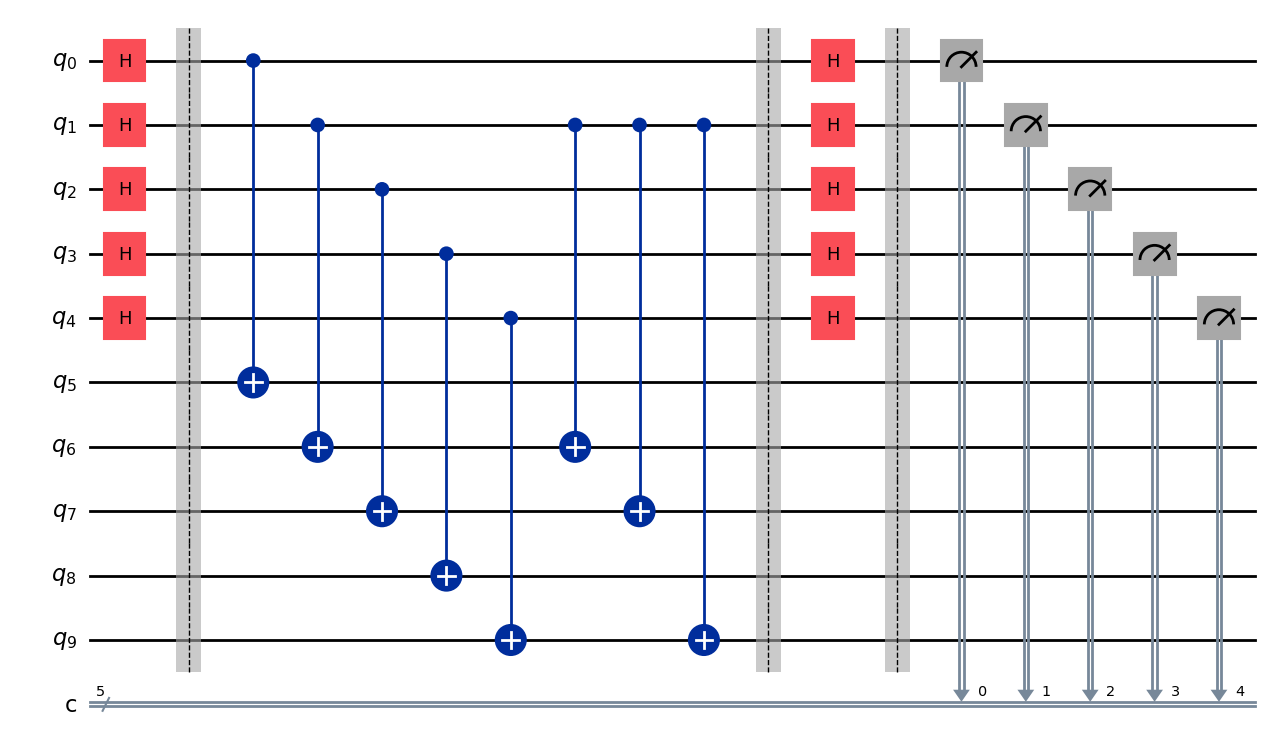

In [12]:
# Apply the second layer of Hadamard gates to the query register
qc_5bit.h(range(n_5bit))
qc_5bit.barrier()

# Measure the query register into the classical bits
qc_5bit.measure(range(n_5bit), range(n_5bit))

# Draw the 10-qubit circuit
qc_5bit.draw('mpl')

### 4. Execution and Extracting Equations
[cite_start]We execute the circuit using 2000 shots[cite: 854]. [cite_start]The resulting bitstrings ($u$) will all satisfy the equation $u \cdot s = 0 \pmod 2$[cite: 859]. 

Note: We must exclude the trivial outcome `00000` from our final equations, as it does not provide any useful information about the secret string.

Measured bitstrings for s = '10110':

Valid 'u' bitstrings (excluding 00000):
['10101', '11101', '10100', '01000', '10011', '11100', '00111', '01001', '11010', '01110', '10010', '00110', '01111', '11011', '00001']


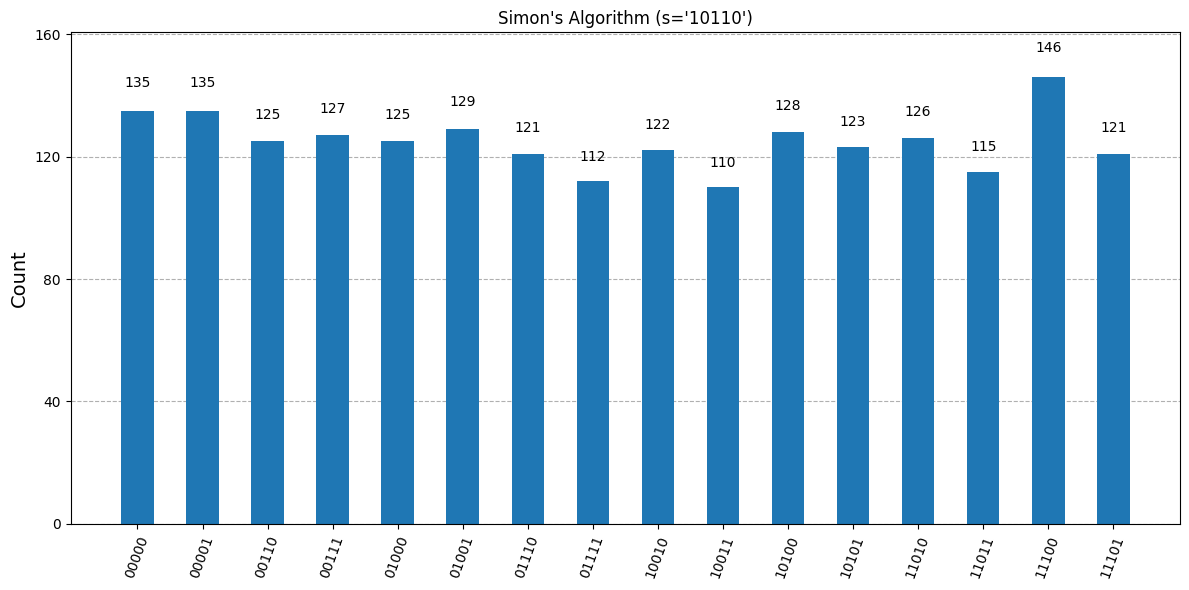

In [13]:
# Set up the simulator
backend = Aer.get_backend('aer_simulator')

# Execute the circuit with 2000 shots
job_5bit = backend.run(qc_5bit, shots=2000)
counts_5bit = job_5bit.result().get_counts()

print(f"Measured bitstrings for s = '{s_5bit}':")

# Print the keys (the bitstrings 'u') directly so we can use them for Part C
valid_u_strings = [u for u in counts_5bit.keys() if u != '00000']
print("\nValid 'u' bitstrings (excluding 00000):")
print(valid_u_strings)

# Plot the histogram
plot_histogram(counts_5bit, title="Simon's Algorithm (s='10110')", figsize=(12, 6))

# Assignment 2, Part C: Classical Post-Processing
### 1. Extracting the Measured Bitstrings
From Part B, we executed our Simon's Algorithm circuit for the secret string $s = 10110$. We successfully measured a set of valid bitstrings ($u$) that satisfy the equation $u \cdot s = 0 \pmod 2$. 

First, we will store these measured strings (excluding the trivial `00000` outcome) in a list to construct our system of equations.

In [16]:
# The valid bitstrings 'u' extracted directly from your Part B execution
valid_u_strings = [
    '00001', '01000', '01001', '00110', '00111', 
    '01110', '01111', '10010', '10011', '11010', 
    '11011', '10100', '10101', '11100', '11101'
]

print(f"Total unique equations: {len(valid_u_strings)}")

Total unique equations: 15


### 2. Solving the System of Equations Modulo 2
We need to solve the matrix equation $Us = 0 \pmod 2$. 

Because our string is exactly 5 bits long, there are only $2^5 - 1 = 31$ possible non-zero candidates for $s$. We can write a classical Python script to iterate through all 31 possible 5-bit strings, calculating the dot product of each candidate against all of our measured $u$ strings. 

The candidate that results in a dot product of `0 (mod 2)` for *every single* $u$ string is our mathematically recovered secret string $s$.

In [17]:
n = 5

# Step 1: Generate all possible non-zero 5-bit strings (from 1 to 31)
possible_s_candidates = [format(i, f'0{n}b') for i in range(1, 2**n)]

recovered_s = []

# Step 2: Test each candidate against our system of equations
for candidate in possible_s_candidates:
    is_valid = True
    
    for u in valid_u_strings:
        # Calculate the dot product modulo 2 for u * candidate
        dot_product = sum(int(u[i]) * int(candidate[i]) for i in range(n)) % 2
        
        # If the dot product is not 0, this candidate is incorrect
        if dot_product != 0:
            is_valid = False
            break # Move to the next candidate
            
    # If the candidate satisfied u * s = 0 (mod 2) for ALL strings, we found it!
    if is_valid:
        recovered_s.append(candidate)

print("--- Classical Post-Processing Results ---")
print(f"Recovered Secret String(s): {recovered_s}")

--- Classical Post-Processing Results ---
Recovered Secret String(s): ['10110']


### 3. Conclusion and Verification
The classical post-processing successfully solved the system of linear equations $Us = 0 \pmod 2$ and returned `10110`. 

This perfectly matches the secret string $s$ we originally encoded into our Simon Oracle in Part B, verifying that the quantum algorithm and classical post-processing step worked exactly as intended!